In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from tqdm.auto import tqdm

import scienceplots

plt.style.use(['science', 'no-latex'])

from joblib import Parallel, delayed
import itertools

from time import time

import geodesiq as gq

print(f"The version of geodesiq used in this script is: {gq.__version__}")

The version of geodesiq used in this script is: 0.1.5


Useful functions for the rest of the script

In [3]:
def fidelity_vs_time(durations, model, params: dict | None = None, controls: dict | None = None):
    params = params or {}
    controls = controls or {}

    model.set_parameters(**params)  # x=x, and alike
    model.set_control(**controls)

    model.solve_problem()

    def _worker(duration, model):
        dynamics = gq.Dynamics(duration=duration, model=model)
        return dynamics.state_fidelity()

    fidelities = Parallel(n_jobs=-1)(
        delayed(_worker)(duration, model) for duration in tqdm(durations, desc="Computing fidelities"))

    return np.array(fidelities)

# State transfer intro + Landau-Zener plots

In [4]:
# ----- Define ControlModel -----
def ham(z, x):
    return np.array([[z, x], [x, -z]])


model_lz = gq.ControlModel(ham)

# ----- Set system and control parameters -----
alpha, beta = 2, 2
x = 1
z0, zf = -10, 10

model_lz.set_parameters(x=x)
model_lz.set_control(control_name='z', pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)

In [5]:
# Run the fidelity sweep for FAQUAD and geometric pulses
durations = np.linspace(0.01, 10, 200)
fidelity_linear = fidelity_vs_time(durations, model_lz,
                                   controls={"alpha": 0, "beta": 0})  # Constant metric, ie linear pulse
fidelities_geometric = fidelity_vs_time(durations, model_lz, controls={"alpha": 2, "beta": 2})
fidelities_faquad = fidelity_vs_time(durations, model_lz, controls={"alpha": 4, "beta": 2})

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

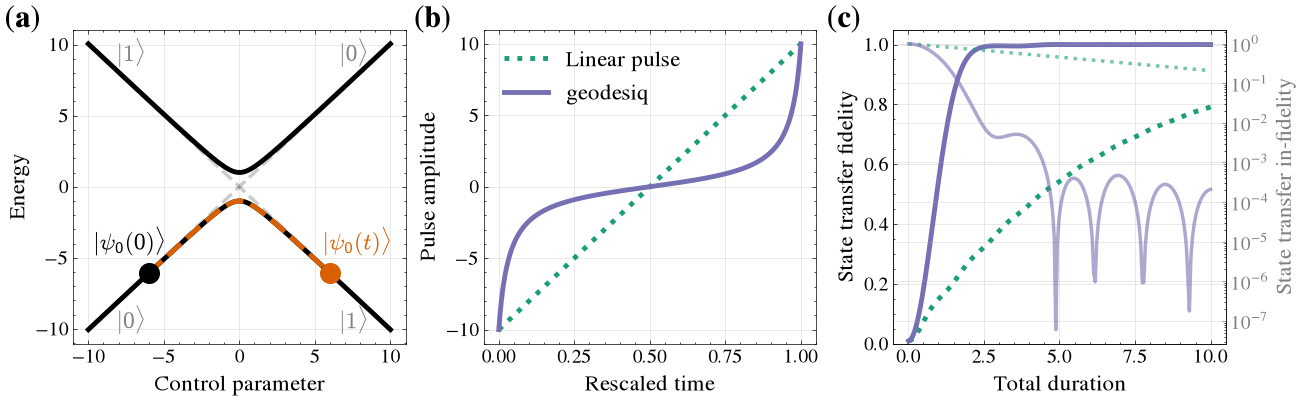

In [6]:
C_SPECTRUM = "#d95f02"  # blue
C_GEOMETRIC = "#7570b3"
C_LINEAR = "#1b9e77"
linewidth = 3.5
fontsize_label = 16


def return_pulse(model):
    return model._control_sol


# Call solve so _control_sol is populated for each model before reading the pulse
model_lz.set_control(alpha=0, beta=0);
model_lz.solve_problem(pulse_accuracy=1000)
pulse_lin = return_pulse(model_lz)
t_lin = np.linspace(0, 1, len(pulse_lin))

model_lz.set_control(alpha=2, beta=2);
model_lz.solve_problem(pulse_accuracy=1000)
pulse_geo = return_pulse(model_lz)
t_geo = np.linspace(0, 1, len(pulse_geo))

fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

# ─────────────────────────────────────────────────────────────────────────────
# (a)  Eigenenergies
# ─────────────────────────────────────────────────────────────────────────────


ax_a.set_xlabel("Control parameter", fontsize=fontsize_label)
ax_a.set_ylabel("Energy", fontsize=fontsize_label)

scatter_size = 200
x = np.linspace(-10, 10, 100)
ax_a.plot(x, np.sqrt(1 + x ** 2), linewidth=linewidth, color='black')
ax_a.plot(x, -np.sqrt(1 + x ** 2), linewidth=linewidth, color='black')
ax_a.plot(x, x, linewidth=linewidth - 1, color='black', alpha=0.2, ls='dashed')
ax_a.plot(x, -x, linewidth=linewidth - 1, color='black', alpha=0.2, ls='dashed')

ax_a.text(0.13, 0.05, r'$|0\rangle$', fontsize=17, color='gray', transform=ax_a.transAxes)
ax_a.text(0.13, 0.9, r'$|1\rangle$', fontsize=17, color='gray', transform=ax_a.transAxes)

ax_a.text(0.8, 0.05, r'$|1\rangle$', fontsize=17, color='gray', transform=ax_a.transAxes)
ax_a.text(0.8, 0.9, r'$|0\rangle$', fontsize=17, color='gray', transform=ax_a.transAxes)

x_plot = np.linspace(-6, 6, 100)
ax_a.plot(x_plot, -np.sqrt(1 + x_plot ** 2), linewidth=linewidth, linestyle='dashed', color=C_SPECTRUM)
ax_a.scatter(x_plot[0], -np.sqrt(1 + x_plot[0] ** 2), zorder=2, s=scatter_size, color='black')
ax_a.text(0.06, 0.3, r'$|\psi_\text{0}(0)\rangle$', fontsize=17, color='black', transform=ax_a.transAxes)
ax_a.scatter(x_plot[-1], -np.sqrt(1 + x_plot[-1] ** 2), color=C_SPECTRUM, zorder=2, s=scatter_size)
ax_a.text(0.75, 0.3, r'$|\psi_\text{0}(t)\rangle$', fontsize=17, color=C_SPECTRUM, transform=ax_a.transAxes)

# ─────────────────────────────────────────────────────────────────────────────
# (b)  Pulse
# ─────────────────────────────────────────────────────────────────────────────
ax_b.plot(t_lin, pulse_lin, color=C_LINEAR, lw=linewidth, label="Linear pulse", ls="dotted")
ax_b.plot(t_geo, pulse_geo, color=C_GEOMETRIC, lw=linewidth, label="geodesiq")

ax_b.set_xlabel("Rescaled time", fontsize=fontsize_label)
ax_b.set_ylabel("Pulse amplitude", fontsize=fontsize_label)
ax_b.legend(frameon=False, fontsize=fontsize_label)

# ─────────────────────────────────────────────────────────────────────────────
# (c)  Fidelity (left) + Infidelity log-scale (right)
# ─────────────────────────────────────────────────────────────────────────────
ax_c_r = ax_c.twinx()

# Left axis — fidelity
ax_c.plot(durations, fidelity_linear, color=C_LINEAR, lw=linewidth, ls="dotted")
ax_c.plot(durations, fidelities_geometric, color=C_GEOMETRIC, lw=linewidth)
ax_c.set_ylim(0, 1.05)
ax_c.set_xlabel("Total duration", fontsize=fontsize_label)
ax_c.set_ylabel("State transfer fidelity", fontsize=fontsize_label)

# Right axis — infidelity (log)
infidelity_linear = 1 - fidelity_linear
infidelity_geometric = 1 - fidelities_geometric

ax_c_r.semilogy(durations, infidelity_linear, color=C_LINEAR, lw=linewidth - 1, alpha=0.6, ls="dotted")
ax_c_r.semilogy(durations, infidelity_geometric, color=C_GEOMETRIC, lw=linewidth - 1, alpha=0.6)
ax_c_r.set_ylabel("State transfer in-fidelity", color="gray", fontsize=fontsize_label)
ax_c_r.tick_params(axis="y", colors="gray")
ax_c_r.yaxis.set_minor_locator(ticker.LogLocator(subs="all"))

for ax in [ax_a, ax_b, ax_c, ax_c_r]:
    ax.tick_params(labelsize=14)
    ax.grid(alpha=0.4)

for i, ax in enumerate([ax_a, ax_b, ax_c]):
    ax.text(-0.1, 1.08, f'({chr(97 + i)})', transform=ax.transAxes, fontsize=22, fontweight='bold', va='top',
            ha='right')

plt.show()

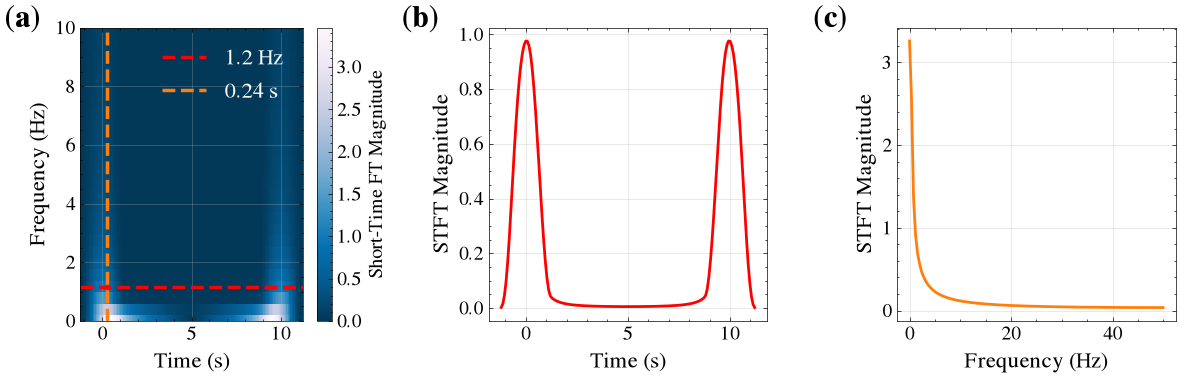

In [7]:
total_time = 10
pulse = model_lz.synthesize_pulse(duration=total_time)
freqs, times, magnitude = pulse.fourier_spectrum(window_len=256, hop=8)

target_freq = 1.0
freq_idx = np.argmin(np.abs(freqs - target_freq))

target_time = 0.25
time_idx = np.argmin(np.abs(times - target_time))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

mesh = axes[0].pcolormesh(times, freqs, magnitude, shading='auto', cmap='PuBu_r')
cbar = fig.colorbar(mesh, ax=axes[0])
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Short-Time FT Magnitude', fontsize=14)

axes[0].axhline(freqs[freq_idx], color='red', lw=linewidth - 1, linestyle='--', label=f'{freqs[freq_idx]:.1f} Hz')
axes[0].axvline(times[time_idx], color='tab:orange', lw=linewidth - 1, linestyle='--', label=f'{times[time_idx]:.2f} s')
axes[0].legend(loc='upper right', fontsize=fontsize_label, labelcolor='white')
axes[0].set_xlabel("Time (s)", fontsize=fontsize_label)
axes[0].set_ylabel("Frequency (Hz)", fontsize=fontsize_label)
axes[0].set_ylim(0, 10)

axes[1].plot(times, magnitude[freq_idx, :], color='red', lw=2)
axes[1].set_xlabel("Time (s)", fontsize=fontsize_label)
axes[1].set_ylabel("STFT Magnitude", fontsize=fontsize_label)
# axes[1].set_title(f"Freq Slice @ {freqs[freq_idx]:.2f} Hz", fontsize=fontsize_label)


axes[2].plot(freqs, magnitude[:, time_idx], color='tab:orange', lw=2)
axes[2].set_xlabel("Frequency (Hz)", fontsize=fontsize_label)
axes[2].set_ylabel("STFT Magnitude", fontsize=fontsize_label)
# axes[2].set_title(f"Time Slice @ {times[time_idx]:.2f} s", fontsize=fontsize_label)


for ax in axes:
    ax.tick_params(labelsize=14)
    ax.grid(alpha=0.4)

for i, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.08, f'({chr(97 + i)})', transform=ax.transAxes, fontsize=22, fontweight='bold', va='top',
            ha='right')

plt.tight_layout()
plt.show()

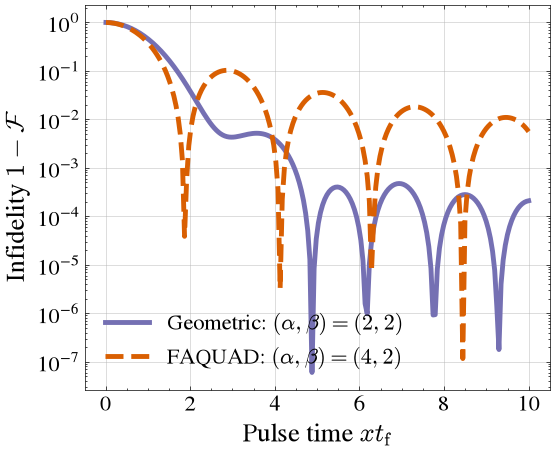

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(durations, 1 - fidelities_geometric, label=r'Geometric: $(\alpha,\beta)=(2,2)$', lw=linewidth,
        color=C_GEOMETRIC)
ax.plot(durations, 1 - fidelities_faquad, label=r'FAQUAD: $(\alpha,\beta)=(4,2)$', lw=linewidth, ls='dashed',
        color=C_SPECTRUM)

ax.set_yscale('log')
ax.set_ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=fontsize_label + 3)
ax.set_xlabel(r'Pulse time $x t_\text{f}$', fontsize=fontsize_label + 3)
ax.legend(fontsize=fontsize_label)
ax.grid(alpha=0.6)
ax.tick_params(labelsize=16)

plt.show()

# DQD plots

In [9]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array([[U - eps, 0, -tc, tc, 0], [0, Ez, dEx, -dEx, 0], [-tc, dEx, dEz, 0, dEx], [tc, -dEx, 0, -dEz, -dEx],
                    [0, 0, dEx, -dEx, -Ez]])
    return ham


dqd_model = gq.ControlModel(dqd_hamiltonian)

# ----- Set system and control parameters -----
alpha, beta = 2, 2

U, tc, Ez, dEz, dEx = 10, 1, .9, .1, .01
eps0, epsf = 15, 0

dqd_model.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_model.set_control(control_name='eps', pulse_initial=eps0, pulse_final=epsf, initial_state=0, alpha=alpha, beta=beta)

In [10]:
durations = np.linspace(0.01, 1000, 200)

fidelities_dqd_geometric = fidelity_vs_time(durations, dqd_model, controls={"alpha": 2, "beta": 2})
fidelities_dqd_faquad = fidelity_vs_time(durations, dqd_model, controls={"alpha": 4, "beta": 2})

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
def optimal_fidelity_time_map(durations, model, alphas, betas, n_jobs=-1):
    """
    Function that computes the fidelity map for a range of alpha and beta values over a range of durations.
    The function relies on the definition of fidelity_vs_time() from above.
    """

    def _worker(durations, model, alpha=2, beta=2):
        model.set_control(alpha=alpha, beta=beta)
        model.solve_problem(pulse_accuracy=int(1000))

        fidelities = []
        for duration in durations:
            dynamics = gq.Dynamics(duration=duration, model=model)
            fidelities.append(dynamics.state_fidelity())

        return np.array(fidelities)

    pairs = list(itertools.product(alphas, betas))

    results = Parallel(n_jobs=n_jobs)(delayed(_worker)(durations, model, alpha=alpha, beta=beta) for alpha, beta in
                                      tqdm(pairs, desc="Computing optimal fidelities"))

    fidelities = np.array(results).reshape(len(alphas), len(betas), len(durations))

    max_fidelities = np.max(fidelities, axis=2)
    best_times = durations[np.argmax(fidelities, axis=2)]

    return max_fidelities, best_times

In [16]:
durations_2d = np.linspace(0.01, 1000, 25)

alphas = np.linspace(0, 4, 7)
betas = np.linspace(0, 4, 7)

optimal_fidelities, best_times = optimal_fidelity_time_map(durations_2d, dqd_model, alphas, betas)

Computing optimal fidelities:   0%|          | 0/49 [00:00<?, ?it/s]

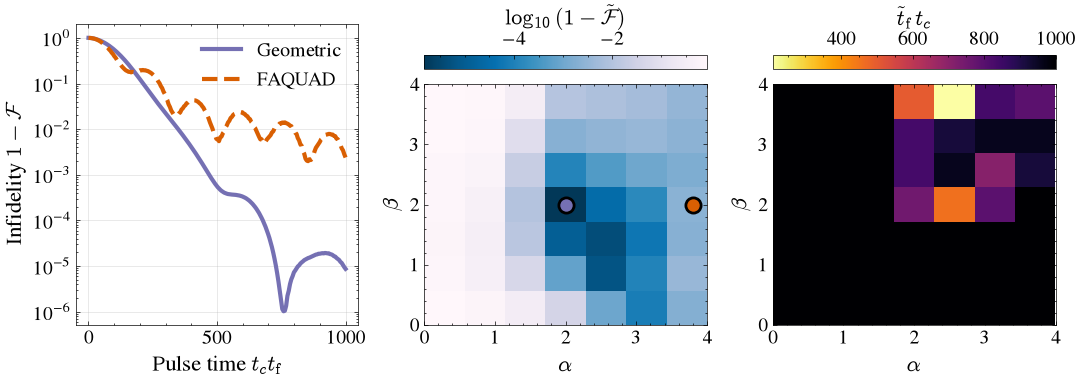

In [17]:
C_SPECTRUM = "#d95f02"
C_GEOMETRIC = "#7570b3"
C_LINEAR = "#1b9e77"
linewidth = 3.5
fontsize_label = 16

fontsizes = 14
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig, axs = plt.subplots(1, 3, figsize=(11, 4))

axs[0].plot(durations, 1 - fidelities_dqd_geometric, label=r'Geometric', lw=3, color=C_GEOMETRIC)
axs[0].plot(durations, 1 - fidelities_dqd_faquad, label=r'FAQUAD', lw=3, ls='--', color=C_SPECTRUM)
axs[0].set_yscale('log')
axs[0].set_ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=fontsize_label)
axs[0].set_xlabel(r'Pulse time $t_c t_\text{f}$', fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)
axs[0].grid(alpha=0.4)
axs[0].legend(fontsize=14)

infidelity_opt = np.log10(1 - optimal_fidelities.T)

im1 = axs[1].imshow(infidelity_opt, origin='lower', aspect='auto', interpolation='none', extent=extent,
                    cmap=cmap_coloring_fid)
axs[1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[1].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

axs[1].scatter(2, 2, s=120, label='Geometric', edgecolor='black', linewidths=2, color=C_GEOMETRIC)
axs[1].scatter(3.8, 2, s=120, label='FAQUAD', edgecolor='black', linewidths=2, color=C_SPECTRUM)

cbar1 = plt.colorbar(im1, ax=axs[1], location=colorbar_loc, pad=0.05)
cbar1.set_label(r'$\log_{10}(1 - \tilde{\mathcal{F}})$', size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)

im2 = axs[2].imshow(best_times.T, origin='lower', aspect='auto', interpolation='none', extent=extent, cmap='inferno_r')
axs[2].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[2].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[2].tick_params(labelsize=fontsizes)

cbar2 = plt.colorbar(im2, ax=axs[2], location=colorbar_loc, pad=0.05)
cbar2.set_label(r'$\tilde{t}_\text{f}\,t_c$', size=fontsize_label)
cbar2.ax.tick_params(labelsize=fontsizes)

plt.tight_layout()
plt.show();

# Many-body spin chain

In [18]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian


def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising ControlModel with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()


def get_model(L, ising_model):
    model = gq.ControlModel(ising_model)

    alpha, beta = 2, 2
    initial_state = 0

    hx, hz = 1, .8
    lam0, lamf = 0, 1

    model.set_parameters(hx=hx, hz=hz)
    model.set_control(control_name='lam', pulse_initial=lam0, pulse_final=lamf, initial_state=initial_state,
                      alpha=alpha, beta=beta, num_steps=2 ** 4 + 1)

    model.set_parameters(L=L)

    return model

In [19]:
def fidelity_vs_time_L(durations, L, ising_model, n_jobs=-1):
    model = get_model(L, ising_model)
    model.solve_problem(pulse_accuracy=int(100))

    def _worker_compute_fidelity(duration, model):
        dynamics = gq.Dynamics(duration=duration, model=model)
        return dynamics.state_fidelity()

    # Run the loop in parallel with joblib
    fidelities = Parallel(n_jobs=n_jobs)(delayed(_worker_compute_fidelity)(duration, model) for duration in
                                         tqdm(durations, desc=f"Computing fidelities (L={L})"))

    return np.array(fidelities)


def pulses_and_runtime(Ls, ising_model, num_samples=100):
    runtimes = []
    control_pulses = []

    def _worker_runtime():
        start_time = time()
        model = get_model(L, ising_model)
        model.solve_problem(pulse_accuracy=int(100))
        final_time = time() - start_time
        pulse = model._control_sol
        return final_time, pulse

    for L in Ls:
        # Run the loop in parallel with joblib
        results = Parallel(n_jobs=-1)(
            delayed(_worker_runtime)() for _ in tqdm(range(num_samples), desc=f"Computing runtimes (L={L})"))

        # Unzip the results into two separate lists
        times, pulses = zip(*results)
        runtimes.append(np.array(times))
        control_pulses.append(pulses[0])  # Store the first pulse as a representative

    return np.array(runtimes), np.array(control_pulses)

In [20]:
durations = np.linspace(0.1, 500, 10)
Ls = [2, 4, 6]
fids = []

for L in Ls:
    fids.append(fidelity_vs_time_L(durations=durations, L=L, ising_model=ising_model))

Computing fidelities (L=2):   0%|          | 0/10 [00:00<?, ?it/s]

Computing fidelities (L=4):   0%|          | 0/10 [00:00<?, ?it/s]

Computing fidelities (L=6):   0%|          | 0/10 [00:00<?, ?it/s]

In [21]:
Ls_runtime = [2, 4, 6]
runtimes, control_pulses = pulses_and_runtime(Ls=Ls_runtime, ising_model=ising_model)

Computing runtimes (L=2):   0%|          | 0/100 [00:00<?, ?it/s]

Computing runtimes (L=4):   0%|          | 0/100 [00:00<?, ?it/s]

Computing runtimes (L=6):   0%|          | 0/100 [00:00<?, ?it/s]

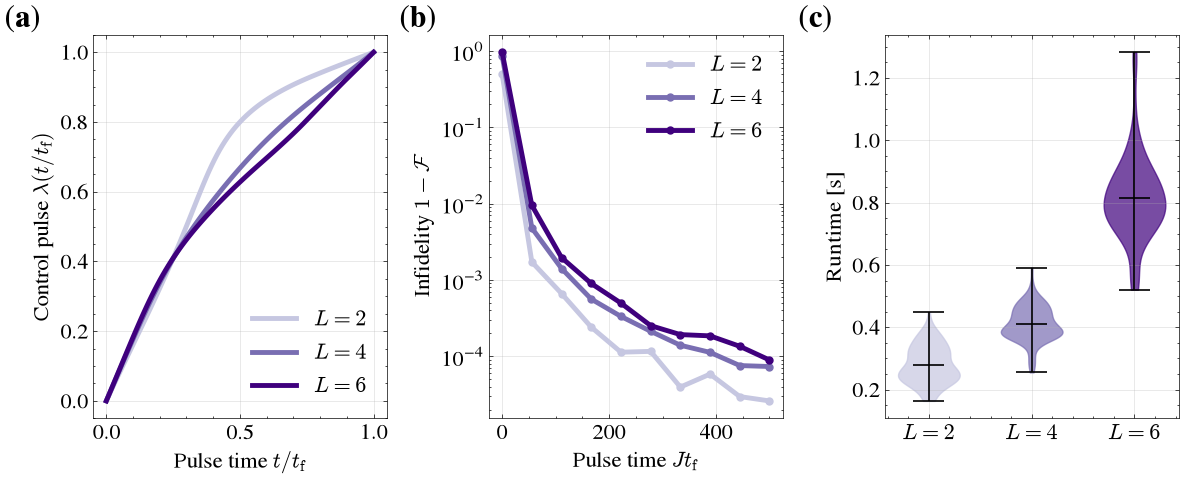

In [22]:
import matplotlib.cm as cm

linewidth = 3.5
fontsize_label = 16

L_vals = np.array(Ls)
norm = plt.Normalize(vmin=L_vals.min() - 2, vmax=L_vals.max())
colors_rgba = cm.Purples(norm(L_vals))

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# ---- a) Control pulses ----
ax = axes[0]
for i, L in enumerate(Ls):
    pulse = control_pulses[i]
    t_pulse = np.linspace(0, 1, len(pulse))
    ax.plot(t_pulse, pulse, lw=linewidth, color=colors_rgba[i], label=f'$L={L}$')
ax.set_xlabel(r'Pulse time $t/t_\text{f}$', fontsize=fontsize_label)
ax.set_ylabel(r'Control pulse $\lambda(t/t_\text{f})$', fontsize=fontsize_label)
ax.legend(fontsize=fontsize_label)

# ---- b) Infidelities ----
ax = axes[1]
for i, L in enumerate(Ls):
    ax.plot(durations, 1 - fids[i], lw=linewidth, color=colors_rgba[i], label=f'$L={L}$', marker='o', markersize=5)
ax.set_yscale('log')
ax.set_xlabel(r'Pulse time $Jt_\text{f}$', fontsize=fontsize_label)
ax.set_ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=fontsize_label)
ax.legend(fontsize=fontsize_label)

# ---- c) Runtimes (violin plot) ----
L_vals_runtime = np.array(Ls_runtime)
norm = plt.Normalize(vmin=L_vals_runtime.min() - 2, vmax=L_vals_runtime.max())
colors_rgba = cm.Purples(norm(L_vals_runtime))
ax = axes[2]
x = np.arange(len(Ls_runtime))

parts = ax.violinplot([runtimes[i] for i in range(len(Ls_runtime))], positions=x, widths=0.6, showmeans=True,
                      showextrema=True)

for i, body in enumerate(parts['bodies']):
    body.set_facecolor(colors_rgba[i])
    body.set_edgecolor(colors_rgba[i])
    body.set_alpha(0.7)

for key in ('cmeans', 'cmins', 'cmaxes', 'cbars'):
    parts[key].set_color('black')
    parts[key].set_linewidth(1.2)

ax.set_xticks(x)
ax.set_xticklabels([f'$L={L}$' for L in Ls_runtime])
ax.set_ylabel('Runtime [s]', fontsize=fontsize_label)

for ax in axes:
    ax.tick_params(labelsize=fontsize_label)
    ax.grid(alpha=0.4)

for i, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.08, f'({chr(97 + i)})', transform=ax.transAxes, fontsize=22, fontweight='bold', va='top',
            ha='right')

plt.tight_layout()
plt.show()